<a href="https://colab.research.google.com/github/NigthDragon5000/nanoTabFM/blob/main/nanoTabDPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install faiss-gpu-cu12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.2/581.2 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 MB 8.5 MB/s eta 0:00:00


In [2]:
import random
import numpy as np
import faiss
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score


# ---------------------------------------------------------
# 1. Fake tabular tasks
# ---------------------------------------------------------

def make_task(n_train=2000, n_test=500, n_features=10):
    X = np.random.randn(n_train + n_test, n_features).astype("float32")

    # Each task has a different hidden default rule.
    w = np.random.randn(n_features).astype("float32")
    a, b = np.random.choice(n_features, 2, replace=False)

    z = X @ w + 1.5 * X[:, a] * X[:, b]
    p = 1 / (1 + np.exp(-np.clip(z, -20, 20)))
    y = np.random.binomial(1, p).astype("float32")

    return X[:n_train], y[:n_train], X[n_train:], y[n_train:]


# ---------------------------------------------------------
# 2. Retrieve similar rows with FAISS
# ---------------------------------------------------------

def build_index(X_train):
    index = faiss.IndexFlatL2(X_train.shape[1])
    index.add(np.ascontiguousarray(X_train))
    return index


def retrieve(index, X_train, y_train, X_query, k=128, exclude=None):
    search_k = k + 1 if exclude is not None else k
    _, ids = index.search(np.ascontiguousarray(X_query), search_k)

    if exclude is not None:
        ids = np.array([
            [j for j in row if j != exclude[i]][:k]
            for i, row in enumerate(ids)
        ])

    return (
        torch.tensor(X_train[ids], dtype=torch.float32),
        torch.tensor(y_train[ids], dtype=torch.float32),
    )


# ---------------------------------------------------------
# 3. Minimal TabDPT
# ---------------------------------------------------------

class NanoTabDPT(nn.Module):
    def __init__(self, n_features, d_model=64, heads=4):
        super().__init__()

        # Whole row -> one token
        self.row_embed = nn.Linear(n_features, d_model)

        # Known target is added only to context rows
        self.target_embed = nn.Linear(1, d_model)

        # Context <-> context
        self.context_attn = nn.MultiheadAttention(
            d_model, heads, batch_first=True
        )

        # Query -> context only
        self.query_attn = nn.MultiheadAttention(
            d_model, heads, batch_first=True
        )

        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 1)

    def forward(self, context_x, context_y, query_x):
        # [B, K, F] -> [B, K, D]
        context = self.row_embed(context_x)
        context += self.target_embed(context_y.unsqueeze(-1))

        # Context can see context, but never the query.
        context, _ = self.context_attn(context, context, context)
        context = self.norm(context)

        # Query sees labeled context only.
        query = self.row_embed(query_x).unsqueeze(1)
        query, _ = self.query_attn(query, context, context)
        query = self.norm(query[:, 0])

        return self.head(query).squeeze(-1)


# ---------------------------------------------------------
# 4. One training step
# ---------------------------------------------------------

def train_step(model, optimizer, X, y, index, k=32, batch_size=128):
    model.train()

    idx = np.random.choice(len(X), batch_size, replace=False)
    X_query = X[idx]
    y_query = y[idx]

    context_x, context_y = retrieve(
        index, X, y, X_query, k=k, exclude=idx
    )

    logits = model(
        context_x,
        context_y,
        torch.tensor(X_query, dtype=torch.float32),
    )

    loss = nn.functional.binary_cross_entropy_with_logits(
        logits, torch.tensor(y_query)
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


# ---------------------------------------------------------
# 5. Test on completely new tasks
# ---------------------------------------------------------

def evaluate(model, tasks, k=32):
    model.eval()
    aucs = []

    with torch.no_grad():
        for X_train, y_train, X_test, y_test in tasks:
            context_x, context_y = retrieve(
                build_index(X_train), X_train, y_train, X_test, k=k
            )

            query_x = torch.tensor(X_test, dtype=torch.float32)
            logits = model(context_x, context_y, query_x)
            prob = torch.sigmoid(logits).numpy()

            aucs.append(roc_auc_score(y_test, prob))

    return float(np.mean(aucs))



In [4]:

# ---------------------------------------------------------
# 6. Small experiment
# ---------------------------------------------------------

def main():
    np.random.seed(42)
    random.seed(42)
    torch.manual_seed(42)

    n_features = 10

    train_tasks = [make_task(n_features=n_features) for _ in range(100)]
    test_tasks = [make_task(n_features=n_features) for _ in range(20)]

    # Build each FAISS index once, not at every training step.
    train_indices = [build_index(task[0]) for task in train_tasks]

    model = NanoTabDPT(n_features)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for step in range(1000):
        task_id = random.randrange(len(train_tasks))
        X_train, y_train, _, _ = train_tasks[task_id]
        loss = train_step(
            model, optimizer, X_train, y_train, train_indices[task_id]
        )

        if (step + 1) % 100 == 0:
            print(f"step {step + 1:4d} | loss {loss:.4f}")

    auc = evaluate(model, test_tasks)
    print(f"Unseen-task mean AUC: {auc:.4f}")


if __name__ == "__main__":
    main()


step  100 | loss 0.3513
step  200 | loss 0.4364
step  300 | loss 0.3998
step  400 | loss 0.6034
step  500 | loss 0.4325
step  600 | loss 0.3680
step  700 | loss 0.4105
step  800 | loss 0.3816
step  900 | loss 0.4212
step 1000 | loss 0.3722
Unseen-task mean AUC: 0.8764


Unseen-task mean AUC: 0.8772


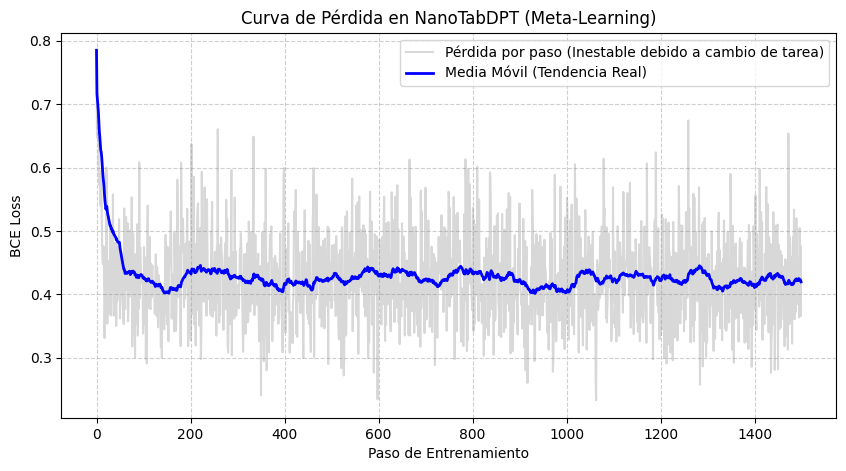

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Vamos a modificar el experimento para guardar el historial completo de pérdidas
# y poder visualizar la curva de aprendizaje de forma suavizada (Moving Average)

def run_tracked_experiment():
    np.random.seed(42)
    random.seed(42)
    torch.manual_seed(42)

    n_features = 10
    train_tasks = [make_task(n_features=n_features) for _ in range(100)]
    test_tasks = [make_task(n_features=n_features) for _ in range(20)]
    train_indices = [build_index(task[0]) for task in train_tasks]

    model = NanoTabDPT(n_features)
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4) # Reducimos un poco el LR para mayor estabilidad

    loss_history = []

    for step in range(1500):
        task_id = random.randrange(len(train_tasks))
        X_train, y_train, _, _ = train_tasks[task_id]
        loss = train_step(
            model, optimizer, X_train, y_train, train_indices[task_id]
        )
        loss_history.append(loss)

    # Evaluación final
    auc = evaluate(model, test_tasks)
    print(f"Unseen-task mean AUC: {auc:.4f}")

    # Graficar pérdidas (Original vs Suavizada)
    df_loss = pd.DataFrame({'loss': loss_history})
    df_loss['smoothed_loss'] = df_loss['loss'].rolling(window=50, min_periods=1).mean()

    plt.figure(figsize=(10, 5))
    plt.plot(df_loss['loss'], alpha=0.3, label='Pérdida por paso (Inestable debido a cambio de tarea)', color='gray')
    plt.plot(df_loss['smoothed_loss'], label='Media Móvil (Tendencia Real)', color='blue', linewidth=2)
    plt.title('Curva de Pérdida en NanoTabDPT (Meta-Learning)')
    plt.xlabel('Paso de Entrenamiento')
    plt.ylabel('BCE Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

run_tracked_experiment()

In [7]:
import torch
import torch.nn as nn
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd

class ImprovedNanoTabDPT(nn.Module):
    def __init__(self, n_features, d_model=64, heads=4):
        super().__init__()

        # Embeddings iniciales
        self.row_embed = nn.Linear(n_features, d_model)
        self.target_embed = nn.Linear(1, d_model)

        # TabDPT se beneficia de pre-layer normalization antes de aplicar la atención (Pre-LN)
        self.context_norm = nn.LayerNorm(d_model)
        self.context_attn = nn.MultiheadAttention(d_model, heads, batch_first=True)

        self.query_norm = nn.LayerNorm(d_model)
        self.query_attn = nn.MultiheadAttention(d_model, heads, batch_first=True)

        self.final_norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 1)

    def forward(self, context_x, context_y, query_x):
        # 1. Crear embeddings de contexto sumando atributos y target
        ctx_features = self.row_embed(context_x)
        ctx_targets = self.target_embed(context_y.unsqueeze(-1))

        # Escalamos para que el target no sature la representación de atributos
        context = ctx_features + 0.1 * ctx_targets
        context = self.context_norm(context)

        # 2. Auto-atención del contexto
        context_updated, _ = self.context_attn(context, context, context)
        context = context + context_updated  # Conexión residual

        # 3. Atención Query -> Contexto
        query = self.row_embed(query_x).unsqueeze(1)
        query = self.query_norm(query)

        query_updated, _ = self.query_attn(query, context, context)
        query = query + query_updated  # Conexión residual

        query = self.final_norm(query[:, 0])
        return self.head(query).squeeze(-1)

Improved NanoTabDPT Unseen-task mean AUC: 0.8743


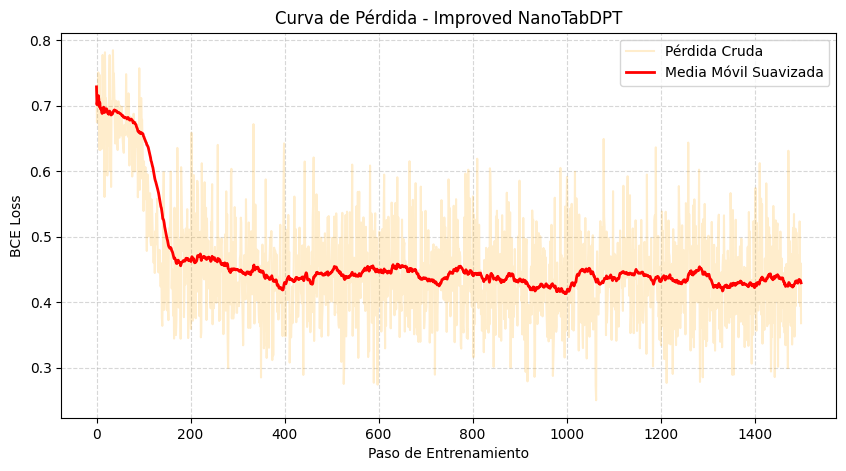

In [6]:


# Función para entrenar esta versión mejorada
def run_improved_experiment():
    np.random.seed(42)
    random.seed(42)
    torch.manual_seed(42)

    n_features = 10
    train_tasks = [make_task(n_features=n_features) for _ in range(100)]
    test_tasks = [make_task(n_features=n_features) for _ in range(20)]
    train_indices = [build_index(task[0]) for task in train_tasks]

    model = ImprovedNanoTabDPT(n_features)
    # Usamos AdamW con Weight Decay para regularizar los pesos del Transformer
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    loss_history = []

    for step in range(1500):
        task_id = random.randrange(len(train_tasks))
        X_train, y_train, _, _ = train_tasks[task_id]

        # Copia del train_step adaptada al nuevo modelo
        model.train()
        idx = np.random.choice(len(X_train), 128, replace=False)
        X_query = X_train[idx]
        y_query = y_train[idx]

        context_x, context_y = retrieve(
            train_indices[task_id], X_train, y_train, X_query, k=32, exclude=idx
        )

        logits = model(
            context_x,
            context_y,
            torch.tensor(X_query, dtype=torch.float32),
        )

        loss = nn.functional.binary_cross_entropy_with_logits(
            logits, torch.tensor(y_query)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

    # Evaluación final en tareas no vistas
    auc = evaluate(model, test_tasks)
    print(f"Improved NanoTabDPT Unseen-task mean AUC: {auc:.4f}")

    # Graficar resultados suavizados
    df_loss = pd.DataFrame({'loss': loss_history})
    df_loss['smoothed_loss'] = df_loss['loss'].rolling(window=50, min_periods=1).mean()

    plt.figure(figsize=(10, 5))
    plt.plot(df_loss['loss'], alpha=0.2, color='orange', label='Pérdida Cruda')
    plt.plot(df_loss['smoothed_loss'], color='red', linewidth=2, label='Media Móvil Suavizada')
    plt.title('Curva de Pérdida - Improved NanoTabDPT')
    plt.xlabel('Paso de Entrenamiento')
    plt.ylabel('BCE Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

run_improved_experiment()

In [ ]:
from sklearn.preprocessing import StandardScaler

def retrieve_with_scaling(index, X_train, y_train, X_query, k=128, exclude=None):
    """
    Recupera los vecinos más cercanos aplicando un StandardScaler local
    calculado sobre el contexto para asegurar invarianza de escala.
    """
    search_k = k + 1 if exclude is not None else k
    _, ids = index.search(np.ascontiguousarray(X_query), search_k)

    if exclude is not None:
        ids = np.array([
            [j for j in row if j != exclude[i]][:k]
            for i, row in enumerate(ids)
        ])

    # Inicializar tensores de salida
    batch_size = len(X_query)
    n_features = X_train.shape[1]

    context_x_scaled = np.zeros((batch_size, k, n_features), dtype=np.float32)
    query_x_scaled = np.zeros((batch_size, n_features), dtype=np.float32)

    # Ajustamos un escalador para cada grupo local de contexto
    for i in range(batch_size):
        scaler = StandardScaler()
        # Ajustar con el contexto recuperado de esta consulta en particular
        context_local = X_train[ids[i]]
        scaler.fit(context_local)

        # Escalar tanto el contexto como el elemento query correspondiente
        context_x_scaled[i] = scaler.transform(context_local)
        query_x_scaled[i] = scaler.transform(X_query[i].reshape(1, -1))

    return (
        torch.tensor(context_x_scaled, dtype=torch.float32),
        torch.tensor(y_train[ids], dtype=torch.float32),
        torch.tensor(query_x_scaled, dtype=torch.float32)
    )